# Clase 7 · Series Temporales I
### Diplomado de Python y Análisis de Datos — Universidad Marista

Dataset: `ventas_historicas.csv` (columnas: `fecha`, `ventas`, `unidades`,
`promociones`, `temperatura`, `region`)

**Instrucciones para el profesor:** todas las celdas de código están
comentadas (`#`). Ve descomentando cada bloque en el momento del
avance de la clase que corresponda. El orden sigue exactamente el de
la presentación.

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose


# Localiza la carpeta 'datos/' sin importar desde donde se haya
# lanzado Jupyter (VS Code suele usar la raiz del proyecto, no
# la carpeta notebooks/, por lo que "../datos" a veces falla).
_candidatos = [
    Path("../datos"),
    Path("datos"),
    Path.cwd() / "datos",
    Path.cwd().parent / "datos",
]

DATA_DIR = None
for _c in _candidatos:
    if (_c / "ventas_historicas.csv").exists() or (_c / "ventas_tienda.csv").exists():
        DATA_DIR = _c.resolve()
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontro la carpeta 'datos/'. Revisa desde donde "
        "arrancaste Jupyter y ajusta _candidatos si hace falta, o "
        "define DATA_DIR manualmente, ej: DATA_DIR = Path(r'C:/ruta/a/datos')"
    )

print("Usando datos en:", DATA_DIR)


Usando datos en: C:\Users\Victus\Desktop\taller_pandas_csv\clase7_series_temporales\datos


## Fechas con Pandas

### Cargar datos temporales

In [238]:
df = pd.read_csv(DATA_DIR / "ventas_historicas.csv")

print(df.head())

print(df.dtypes)

        fecha  ventas  unidades  promociones  temperatura region
0  2024-01-01   53.99         5            0         12.9  Oeste
1  2024-01-02   49.61         5            0         12.1   Este
2  2024-01-03   71.63         7            0         15.5  Oeste
3  2024-01-04   73.74         9            0         14.2   Este
4  2024-01-05   85.49         5            0         12.8   Este
fecha           object
ventas         float64
unidades         int64
promociones      int64
temperatura    float64
region          object
dtype: object


### Convertir a datetime

In [239]:
df["fecha"] = pd.to_datetime(
    df["fecha"]
)

print(
    df["fecha"].dtype
)

datetime64[ns]


### Extraer componentes de fecha

In [240]:
df["anio"] = (
    df["fecha"].dt.year
)

df["mes"] = (
    df["fecha"].dt.month
)

df["dia"] = (
    df["fecha"].dt.day
)

df["dia_semana"] = (
    df["fecha"].dt.day_name()
)

## Índice temporal

### Convertir la fecha en índice

In [241]:
df = df.set_index(
    "fecha"
)

print(df.head())

print(df.index)

            ventas  unidades  promociones  temperatura region  anio  mes  dia  \
fecha                                                                           
2024-01-01   53.99         5            0         12.9  Oeste  2024    1    1   
2024-01-02   49.61         5            0         12.1   Este  2024    1    2   
2024-01-03   71.63         7            0         15.5  Oeste  2024    1    3   
2024-01-04   73.74         9            0         14.2   Este  2024    1    4   
2024-01-05   85.49         5            0         12.8   Este  2024    1    5   

           dia_semana  
fecha                  
2024-01-01     Monday  
2024-01-02    Tuesday  
2024-01-03  Wednesday  
2024-01-04   Thursday  
2024-01-05     Friday  
DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '20

### Seleccionar por fechas

In [242]:
ventas_2024 = df.loc[
    "2024"
]

ventas_agosto = df.loc[
    "2024-08-01":"2024-08-31"
]

## Resampling

### Ventas mensuales

In [243]:
ventas_mensuales = (
    df["ventas"]
    .resample("ME")
    .sum()
)

print(
    ventas_mensuales.head()
)

fecha
2024-01-31    2503.15
2024-02-29    2756.00
2024-03-31    3456.53
2024-04-30    4092.90
2024-05-31    4673.62
Freq: ME, Name: ventas, dtype: float64


### Promedio semanal

In [244]:
ventas_semanales = (
    df["ventas"]
    .resample("W")
    .mean()
)

print(
    ventas_semanales.head()
)

fecha
2024-01-07    68.560000
2024-01-14    78.445714
2024-01-21    84.125714
2024-01-28    94.132857
2024-02-04    91.578571
Freq: W-SUN, Name: ventas, dtype: float64


## Descomposición

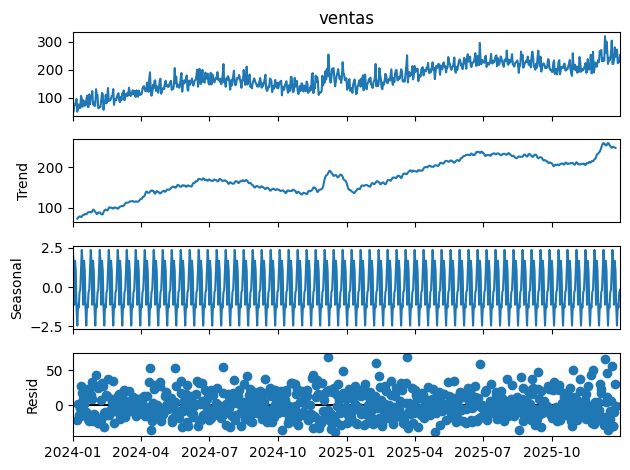

In [245]:
# Nota: period=12 como en el slide. Con datos diarios y patrón semanal también pueden probar period=7 para comparar.

descomposicion = seasonal_decompose(
    df["ventas"],
    model="additive",
    period=12
)

descomposicion.plot()
plt.show()

## Ventanas móviles

### Media móvil en Pandas

In [266]:
df["media_movil_7"] = (
    df["ventas"]
    .rolling(
        window=7
    )
    .mean()
)

### Visualizar la media móvil

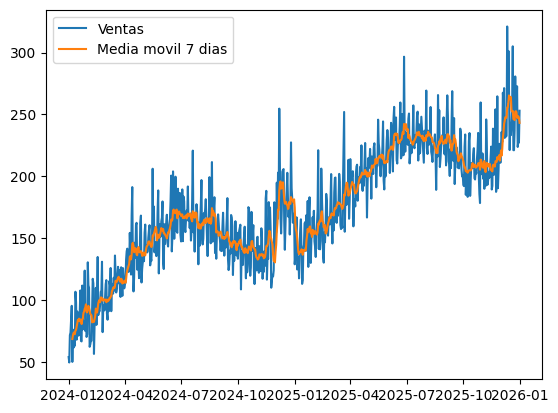

In [286]:
plt.plot(
    df.index,
    df["ventas"],
    label="Ventas"
)

plt.plot(
    df.index,
    df["media_movil_7"],
    label="Media movil 7 dias"
)

plt.legend()

plt.show()

## Diferenciación

In [305]:
df["diferencia"] = (
    df["ventas"]
    .diff()
)

print(
    df[
        ["ventas", "diferencia"]
    ].head()
)

            ventas  diferencia
fecha                         
2024-01-01   53.99         NaN
2024-01-02   49.61       -4.38
2024-01-03   71.63       22.02
2024-01-04   73.74        2.11
2024-01-05   85.49       11.75


## Lag

In [323]:
df["lag_1"] = (
    df["ventas"]
    .shift(1)
)

df["lag_7"] = (
    df["ventas"]
    .shift(7)
)

## Autocorrelación

In [340]:
acf_1 = (
    df["ventas"]
    .autocorr(
        lag=1
    )
)

print(acf_1)

0.8675267171671394


In [356]:
acf_7 = (
    df["ventas"]
    .autocorr(
        lag=7
    )
)

print(acf_7)

0.9035874171967853


## ACF

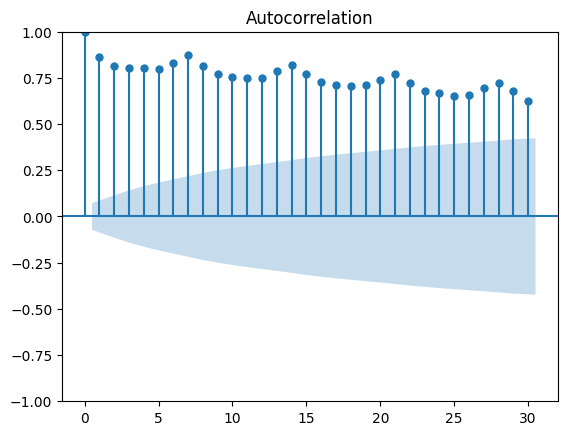

In [371]:
from statsmodels.graphics.tsaplots import (
    plot_acf
)

plot_acf(
    df["ventas"].dropna(),
    lags=30
)

plt.show()

## PACF

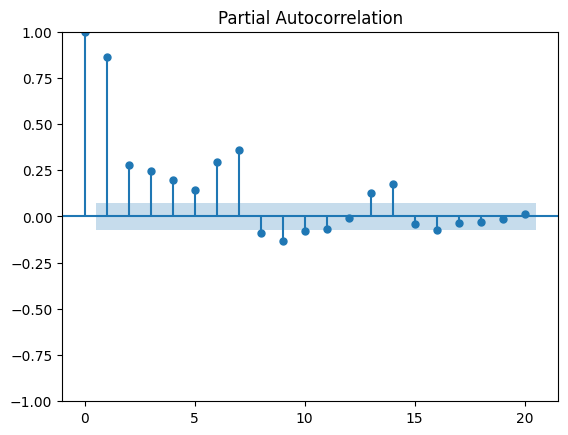

In [385]:
from statsmodels.graphics.tsaplots import (
    plot_pacf
)

plot_pacf(
    df["ventas"].dropna(),
    lags=20
)

plt.show()

## Prueba ADF (Augmented Dickey-Fuller)

In [386]:
# from statsmodels.tsa.stattools import (
#     adfuller
# )

# resultado = adfuller(
#     df["ventas"].dropna()
# )

# print(
#     "ADF:",
#     resultado[0]
# )

# print(
#     "p-value:",
#     resultado[1]
# )

---
## Live Coding: análisis de ventas históricas

A partir de aquí se retoma el dataset desde cero, siguiendo los
10 pasos de la presentación, para armar el pipeline completo
de punta a punta.

### Paso 1: cargar

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = pd.read_csv(
#     DATA_DIR / "ventas_historicas.csv"
# )

# df["fecha"] = pd.to_datetime(
#     df["fecha"]
# )

# df = df.sort_values(
#     "fecha"
# )

# df = df.set_index(
#     "fecha"
# )

# print(df.head())

NameError: name 'DATA_DIR' is not defined

### Paso 2: revisar estructura

In [2]:
print(
    df.shape
)

print(
    df.index.min()
)

print(
    df.index.max()
)

print(
    df.isna().sum()
)

NameError: name 'df' is not defined

### Paso 3: visualizar la serie

In [ ]:
# plt.figure(
#     figsize=(12,5)
# )

# plt.plot(
#     df.index,
#     df["ventas"]
# )

# plt.title(
#     "Ventas historicas"
# )

# plt.xlabel("Fecha")
# plt.ylabel("Ventas")

# plt.show()

### Paso 4: ventas mensuales

In [ ]:
# mensual = (
#     df["ventas"]
#     .resample("ME")
#     .sum()
# )

# plt.plot(
#     mensual.index,
#     mensual
# )

# plt.title(
#     "Ventas mensuales"
# )

# plt.show()

### Paso 5: media móvil

In [ ]:
# df["ma_7"] = (
#     df["ventas"]
#     .rolling(7)
#     .mean()
# )

# df["ma_30"] = (
#     df["ventas"]
#     .rolling(30)
#     .mean()
# )

# plt.plot(
#     df["ventas"],
#     alpha=0.4
# )

# plt.plot(
#     df["ma_7"]
# )

# plt.plot(
#     df["ma_30"]
# )

# plt.show()

### Paso 6: diferencia

In [ ]:
# df["diff_1"] = (
#     df["ventas"]
#     .diff()
# )

# plt.plot(
#     df["diff_1"]
# )

# plt.title(
#     "Primera diferencia"
# )

# plt.show()

### Paso 7: autocorrelación

In [ ]:
# print(
#     "Lag 1:",
#     df["ventas"].autocorr(1)
# )

# print(
#     "Lag 7:",
#     df["ventas"].autocorr(7)
# )

# print(
#     "Lag 30:",
#     df["ventas"].autocorr(30)
# )

### Paso 8: ACF y PACF

In [ ]:
# from statsmodels.graphics.tsaplots import (
#     plot_acf,
#     plot_pacf
# )

# plot_acf(
#     df["ventas"].dropna(),
#     lags=30
# )

# plt.show()

# plot_pacf(
#     df["ventas"].dropna(),
#     lags=20
# )

# plt.show()

### Paso 9: ADF

In [ ]:
# from statsmodels.tsa.stattools import (
#     adfuller
# )

# resultado = adfuller(
#     df["ventas"].dropna()
# )

# print(
#     "ADF:",
#     resultado[0]
# )

# print(
#     "p-value:",
#     resultado[1]
# )

### Paso 10: ADF después de diferenciar

In [ ]:
# serie_diff = (
#     df["ventas"]
#     .diff()
#     .dropna()
# )

# resultado = adfuller(
#     serie_diff
# )

# print(
#     "ADF:",
#     resultado[0]
# )

# print(
#     "p-value:",
#     resultado[1]
# )

---
## Time Series Detective Challenge

Afirmación a comprobar: *"Las ventas están creciendo y presentan un
patrón semanal."*

### Ventas por día de la semana

In [ ]:
# df["dia_semana"] = (
#     df.index
#     .day_name()
# )

# ventas_dia = (
#     df.groupby(
#         "dia_semana"
#     )["ventas"]
#     .mean()
# )

# print(
#     ventas_dia
# )

### Preguntas guía para la conclusión final

1. ¿Las ventas realmente están creciendo? *(apóyense en el resample
   mensual y en `ma_30`)*
2. ¿Existe un patrón semanal? *(apóyense en `lag=7`, `autocorr` y el
   groupby por día de la semana)*
3. ¿La serie parece estacionaria? *(comparen el ADF de la serie
   original contra `serie_diff`)*
4. ¿Qué lag parece relacionarse más con el presente: 1, 7, 14 o 30?